# Apple株価に相当する公開時系列データの分析

run_id: `v020-exp-29`。Kaggle参照先: https://www.kaggle.com/datasets?search=apple+stock+historical

価格水準と日次リターンを別々に扱う記述的分析。APIトークン・認証設定は表示・保存しない。Kaggle対応データの検索・取得に失敗した場合のみ指定の公開CSVへ切り替える。データ範囲外の予測、因果推論、投資推奨は行わない。

Notebookの作成・編集は `project_manager.ensure_notebook/enqueue_write`、コードセル実行・実行結果保存はJupyter MCPを使用する。MCPツールはPythonのMCPClientをカーネルへ提供しないため `mcp_gateway.run_and_record` は未使用（偽のクライアントやカーネル内execで代用しない）。全コードをJupyter MCP `execute_cell` で実行する。


In [1]:
# 1. 実行環境とライフサイクル
from pathlib import Path
import os, sys, json, hashlib, io, contextlib, warnings, zipfile
from datetime import datetime, timezone
from dataclasses import asdict
from contextlib import contextmanager
import numpy as np
import pandas as pd
import nbformat
from IPython.display import display, Markdown
REPO = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(REPO / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(REPO / 'benchmark/projects')
from ai_data_scientist import project_manager, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, stats_analysis
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, sensitivity
from ai_data_scientist import visualization, insight_engine, notebook_audit
RUN_ID = 'v020-exp-29'
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-29-apple-stock')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
LANGUAGE = language_router.detect_language('Apple株価の価格と日次リターンを分析してください')
phase_log = []
@contextmanager
def execution_phase(label):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求を検知しました')
    lifecycle.mark_execution_start(RUN_ID)
    phase_log.append({'phase': label, 'event': 'execution_start', 'time': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        phase_log.append({'phase': label, 'event': 'execution_end', 'time': datetime.now(timezone.utc).isoformat()})
def notebook_write(mutation):
    lifecycle.mark_write_start(RUN_ID)
    phase_log.append({'event': 'write_start', 'time': datetime.now(timezone.utc).isoformat()})
    try:
        return project_manager.enqueue_write(handle, mutation)
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_write_end(RUN_ID)
        phase_log.append({'event': 'write_end', 'time': datetime.now(timezone.utc).isoformat()})
print('実行言語:', LANGUAGE)
print('run_id:', RUN_ID)
print('Notebook:', handle.notebook_path)
print('実行方式: Jupyter MCP execute_cell。分析コードの外部実行・subprocess・端末・委譲なし。')

@contextmanager
def data_write_phase(label):
    lifecycle.mark_write_start(RUN_ID)
    phase_log.append({'event': 'write_start', 'phase': label, 'time': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    finally:
        lifecycle.mark_write_end(RUN_ID)
        phase_log.append({'event': 'write_end', 'phase': label, 'time': datetime.now(timezone.utc).isoformat()})


実行言語: ja
run_id: v020-exp-29
Notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-29-apple-stock/notebooks/kaggle-v020-kaggle-exp-29-apple-stock.ipynb
実行方式: Jupyter MCP execute_cell。分析コードの外部実行・subprocess・端末・委譲なし。


In [2]:
# 2. Kaggle SDK認証と公開データ検索（機密出力を抑制）
kaggle_failures = []
kaggle_candidates = []
api = None
kaggle_stage = 'SDK import'
def safe_api_failure(stage, exc):
    response = getattr(exc, 'response', None)
    status = getattr(response, 'status_code', None)
    reason = '認証またはアクセス設定の不足' if isinstance(exc, (OSError, SystemExit)) and stage in ('SDK import', 'authenticate') else 'API呼び出しが成功しなかった（例外本文は機密保護のため非記録）'
    item = {'stage': stage, 'exception_class': type(exc).__name__, 'http_status': status, 'reason': reason}
    kaggle_failures.append(item)
    print(json.dumps(item, ensure_ascii=False))
with execution_phase('kaggle_authenticate_and_search'):
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            kaggle_stage = 'authenticate'
            api.authenticate()
        for query in ['apple stock historical', 'apple stock']:
            kaggle_stage = 'dataset_list'
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                matches = api.dataset_list(search=query, page=1)
            for item in matches:
                ref = getattr(item, 'ref', None)
                if ref and ref not in [x['ref'] for x in kaggle_candidates]:
                    kaggle_candidates.append({'ref': ref, 'title': getattr(item, 'title', ''), 'query': query, 'size_bytes': getattr(item, 'total_bytes', None)})
            if kaggle_candidates:
                break
        print('Kaggle候補（先頭12件）:', json.dumps(kaggle_candidates[:12], ensure_ascii=False, default=str))
        if not kaggle_candidates:
            kaggle_failures.append({'stage': 'dataset_list', 'reason': '該当する公開データ候補なし'})
    except (Exception, SystemExit) as exc:
        safe_api_failure(kaggle_stage, exc)


Kaggle候補（先頭12件）: [{"ref": "tarunpaparaju/apple-aapl-historical-stock-data", "title": "Apple (AAPL) Historical Stock Data", "query": "apple stock historical", "size_bytes": 50651}, {"ref": "noeyislearning/apple-inc-historical-stock", "title": "Apple Inc. Historical Stock", "query": "apple stock historical", "size_bytes": 7399}, {"ref": "shiivvvaam/apple-stock-market-historical-data-1980-2024", "title": "Apple Stock Market Historical Data (1980-2024)", "query": "apple stock historical", "size_bytes": 1299595}, {"ref": "mayankanand2701/apple-stock-price-dataset", "title": "Apple Stock Price Dataset 🔥📱💻🎧📊", "query": "apple stock historical", "size_bytes": 223016}, {"ref": "varpit94/apple-stock-data-updated-till-22jun2021", "title": "APPLE Stock Data", "query": "apple stock historical", "size_bytes": 209623}, {"ref": "amirmotefaker/stock-market-analysis-data", "title": "Stock Market Analysis Data", "query": "apple stock historical", "size_bytes": 6148}, {"ref": "gauravtopre/apple-inc-stock-

In [3]:
# 3. Kaggleファイル一覧・取得・SHA-256とデータ来歴
from urllib.request import urlopen, Request
provenance_path = data_dir / 'provenance.json'
previous_provenance = json.loads(provenance_path.read_text()) if provenance_path.exists() else None
file_lists = []
selected = None
with execution_phase('kaggle_file_discovery_and_acquisition'), data_write_phase('data_artifacts_cell_3'):
    if api is not None and kaggle_candidates:
        for candidate in kaggle_candidates[:5]:
            ref = candidate['ref']
            try:
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    listing = api.dataset_list_files(ref)
                files = getattr(listing, 'files', [])
                file_records = [{'name': getattr(f, 'name', ''), 'total_bytes': getattr(f, 'total_bytes', None)} for f in files]
                file_lists.append({'ref': ref, 'files': file_records})
                print('dataset_list_files:', json.dumps(file_lists[-1], ensure_ascii=False))
                csv_files = [f['name'] for f in file_records if f['name'].lower().endswith('.csv')]
                if not csv_files:
                    kaggle_failures.append({'stage': 'dataset_list_files', 'ref': ref, 'reason': 'CSVなし'})
                    continue
                filename = sorted(csv_files, key=lambda name: ('aapl' not in name.lower() and 'apple' not in name.lower(), name))[0]
                if Path(filename).is_absolute() or '..' in Path(filename).parts:
                    raise ValueError('危険な取得ファイル名')
                stage_dir = data_dir / 'kaggle-download'
                stage_dir.mkdir(exist_ok=True)
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    download_ok = api.dataset_download_file(ref, filename, path=str(stage_dir), force=True, quiet=True)
                local = stage_dir / filename
                if not local.exists():
                    compressed = stage_dir / (Path(filename).name + '.zip')
                    if not compressed.exists():
                        raise FileNotFoundError('SDK取得結果に指定CSVまたはzipがありません')
                    with zipfile.ZipFile(compressed) as archive:
                        names = [n for n in archive.namelist() if Path(n).name == Path(filename).name]
                        if len(names) != 1:
                            raise ValueError('ZIP内の対象CSVを一意に識別できません')
                        content = archive.read(names[0])
                    local = data_dir / Path(filename).name
                    local.write_bytes(content)
                selected = {'source_type': 'kaggle', 'owner_dataset_slug': ref, 'file_name': filename, 'local_path': str(local), 'url': 'https://www.kaggle.com/datasets/' + ref, 'selection_reason': '検索上位のApple単一銘柄の日次CSVを優先。結果の良し悪しで選択していない。'}
                break
            except Exception as exc:
                safe_api_failure('dataset_list_files_or_download:' + ref, exc)
    if selected is None:
        if not kaggle_failures:
            raise RuntimeError('Kaggle API失敗の根拠がないためフォールバックは禁止')
        old_experiment = Path('/home/nahisaho/kaggle/experiments/white-paper.md').read_text(encoding='utf-8')
        fallback_url = 'https://raw.githubusercontent.com/plotly/datasets/master/2014_apple_stock.csv'
        if fallback_url not in old_experiment:
            raise RuntimeError('旧実験文書に指定CSV URLが確認できません')
        with urlopen(Request(fallback_url, headers={'User-Agent': 'Jupytermind public-data-analysis'}), timeout=30) as response:
            content = response.read(10_000_001)
        if len(content) > 10_000_000:
            raise ValueError('取得ファイルが10MBを超えました')
        local = data_dir / '2014_apple_stock.csv'
        local.write_bytes(content)
        selected = {'source_type': 'fallback_public_csv', 'owner_dataset_slug': None, 'file_name': local.name, 'local_path': str(local), 'url': fallback_url, 'fallback_reason': kaggle_failures, 'identity_caveat': '公開CSVとKaggle掲載版の完全な同一性は保証されない'}
    content = Path(selected['local_path']).read_bytes()
    provenance = {**selected, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(content).hexdigest(), 'bytes': len(content), 'kaggle_failures': kaggle_failures, 'kaggle_file_lists': file_lists}
    if previous_provenance:
        provenance['previous_sha256'] = previous_provenance['sha256']
        provenance['rerun_identical_bytes'] = previous_provenance['sha256'] == provenance['sha256']
        if not provenance['rerun_identical_bytes']:
            raise RuntimeError('再取得ファイルSHA-256が初回と異なります。分析の再現性を確認できません')
    provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
    loaded = ingestion.ingest(ingestion.SourceSpec(kind='csv', location=selected['local_path']), row_limit=100_000)
    if loaded.truncated:
        raise ValueError('取り込み上限超過：切り詰められたデータで分析しません')
    raw = loaded.dataframe
    print('取得来歴:', json.dumps(provenance, ensure_ascii=False, indent=2))
    print('取得CSV:', raw.shape, raw.columns.tolist())
    display(raw.head(4))
    display(raw.tail(4))


dataset_list_files: {"ref": "tarunpaparaju/apple-aapl-historical-stock-data", "files": [{"name": "HistoricalQuotes.csv", "total_bytes": 145669}]}
取得来歴: {
  "source_type": "kaggle",
  "owner_dataset_slug": "tarunpaparaju/apple-aapl-historical-stock-data",
  "file_name": "HistoricalQuotes.csv",
  "local_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-29-apple-stock/data/kaggle-download/HistoricalQuotes.csv",
  "url": "https://www.kaggle.com/datasets/tarunpaparaju/apple-aapl-historical-stock-data",
  "selection_reason": "検索上位のApple単一銘柄の日次CSVを優先。結果の良し悪しで選択していない。",
  "retrieved_at_utc": "2026-10-01T21:02:18.937493+00:00",
  "sha256": "9831571599a557aebf26e743f8ada6489e209afa6eef4fd0a866828e9e9f3911",
  "bytes": 145669,
  "kaggle_failures": [],
  "kaggle_file_lists": [
    {
      "ref": "tarunpaparaju/apple-aapl-historical-stock-data",
      "files": [
        {
          "name": "HistoricalQuotes.csv",
          "total_bytes": 145669
        }
      ]
  

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13


,Date,Close/Last,Volume,Open,High,Low
2514,03/04/2010,$30.1014,89591907,$29.8971,$30.1314,$29.8043
2515,03/03/2010,$29.9043,92846488,$29.8486,$29.9814,$29.7057
2516,03/02/2010,$29.8357,141486282,$29.99,$30.1186,$29.6771
2517,03/01/2010,$29.8557,137312041,$29.3928,$29.9286,$29.35


In [4]:
# 4. 型変換・意味的異常検査・データ定義と分析前提
with execution_phase('semantic_quality_and_manifests'), data_write_phase('data_artifacts_cell_4'):
    df = raw.copy()
    df.columns = df.columns.str.strip()
    df = df.rename(columns={'Date': 'date', 'Close/Last': 'close', 'Close': 'close', 'AAPL.Close': 'close', 'AAPL.Open': 'open', 'AAPL.High': 'high', 'AAPL.Low': 'low', 'AAPL.Volume': 'volume', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Volume': 'volume'})
    if 'date' not in df or 'close' not in df:
        raise ValueError('必須列date/closeがありません')
    df['date'] = pd.to_datetime(df['date'], errors='raise')
    for column in ['close', 'open', 'high', 'low', 'volume']:
        if column in df:
            df[column] = pd.to_numeric(df[column].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip(), errors='raise')
    original_order = 'descending' if df.date.is_monotonic_decreasing else 'ascending' if df.date.is_monotonic_increasing else 'mixed'
    cleaning_report = cleaning.clean_dataset(df, operation='drop_duplicates')
    df = cleaning_report.dataframe.sort_values('date').reset_index(drop=True)
    print('清掃影響:', json.dumps({'rows_before': cleaning_report.rows_before, 'rows_after': cleaning_report.rows_after, 'rows_removed': cleaning_report.rows_removed, 'columns_affected': cleaning_report.columns_affected, 'input_order': original_order}, ensure_ascii=False))
    schema = {'date': {'not_null': True, 'unique': True}, 'close': {'not_null': True, 'min': 0.000001}}
    schema.update({col: {'not_null': True, 'min': 0 if col == 'volume' else 0.000001} for col in ['open', 'high', 'low', 'volume'] if col in df})
    semantic_anomalies = data_quality.detect_anomalies(df, schema=schema)
    cross_checks = {'non_finite_numeric': int((~np.isfinite(df.select_dtypes('number'))).any(axis=1).sum()), 'weekend_dates': int((df.date.dt.weekday >= 5).sum()), 'duplicate_dates': int(df.date.duplicated().sum())}
    if {'open', 'high', 'low'} <= set(df.columns):
        cross_checks['ohlc_inconsistent'] = int(((df.low > df.high) | (df.low > df[['open', 'close']].min(axis=1)) | (df.high < df[['open', 'close']].max(axis=1))).sum())
    if 'volume' in df:
        cross_checks['non_integer_volume'] = int((df.volume % 1 != 0).sum())
    print('意味的異常:', json.dumps([asdict(a) for a in semantic_anomalies], ensure_ascii=False))
    print('列横断検査:', json.dumps(cross_checks, ensure_ascii=False))
    if semantic_anomalies or cross_checks['non_finite_numeric'] or cross_checks['duplicate_dates'] or cross_checks.get('ohlc_inconsistent', 0):
        raise ValueError('価格の記述分析に影響する意味的異常を検出しました')
    gaps = df.date.diff().dt.days.dropna()
    print('日付間隔（日）の分布:', gaps.value_counts().sort_index().to_dict())
    print('最大日付間隔:', int(gaps.max()), '日。取引所営業日カレンダーとの完全照合は未実施。欠損営業日と休日を断定しない。')
    exploratory = eda.explore(df)
    print('EDA型と欠損:', json.dumps({'dtypes': exploratory.dtypes, 'missing_summary': exploratory.missing_summary}, ensure_ascii=False))
    display(pd.DataFrame(exploratory.describe))
    F = data_definition.FieldValue
    definition = data_definition.build_manifest(
        source={'owner_dataset_slug': F(provenance['owner_dataset_slug'], 'verified', 'Kaggle SDK API'), 'file_name': F(provenance['file_name'], 'verified', 'dataset_list_files/download_file'), 'sha256': F(provenance['sha256'], 'verified', '取得したCSVの全バイト'), 'retrieved_at': F(provenance['retrieved_at_utc'], 'verified', 'UTC取得時計'), 'license': F(None, 'unknown', 'API一覧にライセンス定義を含めていない')},
        dataset_scope={'ticker': F('AAPL / Apple', 'inferred', 'Kaggleタイトル'), 'observed_period': F([str(df.date.min().date()), str(df.date.max().date())], 'verified', 'CSV日付の最小・最大'), 'frequency': F('隣接する観測取引日（日次相当）', 'inferred', '日付間隔と平日検査'), 'exchange_timezone': F(None, 'unknown', 'CSVにタイムゾーンなし')},
        variables={'date': {'definition': F('CSV Date列を日付として解釈', 'verified', 'CSVヘッダーとパース検証')}, 'close': {'definition': F('Close/Last（終値または最終約定値）', 'inferred', 'ヘッダー'), 'unit': F('USDと思われる価格単位', 'inferred', 'ドル記号とApple銘柄'), 'split_adjustment': F(None, 'unknown', 'Adj Close列・調整規則の記載なし'), 'dividend_adjustment': F(None, 'unknown', '配当再投資は検証できない')}, 'volume': {'unit': F('株数と思われる', 'inferred', 'Volume列名と非負整数'), 'adjustment': F(None, 'unknown', '分割に伴う出来高調整規則は不明')}, 'simple_return': {'definition': F('close_t / close_(t-1) - 1', 'verified', '分析式'), 'unit': F('無次元（図表では%）', 'verified', '分析式')}, 'log_return': {'definition': F('ln(close_t / close_(t-1))', 'verified', '分析式')}},
        transformations=('列名の前後空白除去、ドル記号・桁区切り除去、日付・数値型変換', '完全重複行のみ削除、日付昇順。補間・休日追加・欠損価格補完は行わない'))
    print('データ定義manifest:', json.dumps(asdict(definition), ensure_ascii=False, default=str, indent=2))
    print('unknown（unresolved_fields）:', [name for name, value in definition.unresolved_fields()])
    inferred_fields = [f'{section_name}.{name}.{key}' for section_name, section in [('variables', definition.variables)] for name, fields in section.items() for key, value in fields.items() if value.status == 'inferred']
    inferred_fields += [f'{section_name}.{name}' for section_name, section in [('source', definition.source), ('dataset_scope', definition.dataset_scope)] for name, value in section.items() if value.status == 'inferred']
    print('inferredも別途注意喚起:', inferred_fields)
    assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'objective': '観測範囲の価格と日次変動の記述', 'forecast': False, 'return_basis': '取得CSVのClose/Last。総収益率ではない'},
        assumptions=(analysis_assumptions.Assumption('A1', '日付順序・正の価格・日付一意性・OHLCを検査', 'verified', conclusion_critical=True), analysis_assumptions.Assumption('A2', '欠損営業日なし・同じ調整基準の価格系列として比較できる', 'assumed', impact_if_false='日次リターンと長期価格変化が市場実績と一致しない可能性', conclusion_critical=True), analysis_assumptions.Assumption('A3', '外れ値は削除せず観測値として扱う', 'verified'), analysis_assumptions.Assumption('A4', '価格リターンのみ。配当再投資や現在の株価への外挿をしない', 'verified'), analysis_assumptions.Assumption('A5', '分布とボラティリティの期間依存性は追加分析で検証する', 'assumed', impact_if_false='全期間要約が直近や部分期間を代表しない', conclusion_critical=True)), causal_scope='descriptive', sampling={'n': len(df), 'seed': None, 'method': '全行'})
    assumption_findings = analysis_assumptions.check_manifest(assumptions)
    print('分析前提manifest:', json.dumps(asdict(assumptions), ensure_ascii=False, indent=2))
    print('前提検査の全finding:', json.dumps([asdict(f) for f in assumption_findings], ensure_ascii=False, indent=2))
    (data_dir / 'data-definition-manifest.json').write_text(json.dumps(asdict(definition), ensure_ascii=False, default=str, indent=2))
    (data_dir / 'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumptions), ensure_ascii=False, indent=2))


清掃影響: {"rows_before": 2518, "rows_after": 2518, "rows_removed": 0, "columns_affected": ["date", "close", "volume", "open", "high", "low"], "input_order": "descending"}
意味的異常: []
列横断検査: {"non_finite_numeric": 0, "weekend_dates": 0, "duplicate_dates": 0, "ohlc_inconsistent": 0, "non_integer_volume": 0}
日付間隔（日）の分布: {1.0: 1970, 2.0: 26, 3.0: 456, 4.0: 64, 5.0: 1}
最大日付間隔: 5 日。取引所営業日カレンダーとの完全照合は未実施。欠損営業日と休日を断定しない。
EDA型と欠損: {"dtypes": {"date": "datetime64[us]", "close": "float64", "volume": "int64", "open": "float64", "high": "float64", "low": "float64"}, "missing_summary": {"date": {"missing_count": 0, "missing_ratio": 0.0}, "close": {"missing_count": 0, "missing_ratio": 0.0}, "volume": {"missing_count": 0, "missing_ratio": 0.0}, "open": {"missing_count": 0, "missing_ratio": 0.0}, "high": {"missing_count": 0, "missing_ratio": 0.0}, "low": {"missing_count": 0, "missing_ratio": 0.0}}}
データ定義manifest: {
  "source": {
    "owner_dataset_slug": {
      "value": "tarunpaparaju/apple-aapl-historical

,date,close,volume,open,high,low
count,2518,2518.000000,2.518000e+03,2518.000000,2518.000000,2518.000000
mean,2015-02-26 15:01:17.204130,114.769522,7.258009e+07,114.728443,115.766415,113.690582
min,2010-03-01 00:00:00,29.835700,1.136205e+07,29.392800,29.928600,28.464300
25%,2012-08-24 18:00:00,66.822475,3.053026e+07,66.877150,67.475300,66.372950
50%,2015-02-28 12:00:00,101.090000,5.295469e+07,101.115000,102.085000,100.350000
75%,2017-08-27 06:00:00,154.630000,9.861006e+07,154.610000,155.735000,153.325000
max,2020-02-28 00:00:00,327.200000,4.624423e+08,324.740000,327.850000,323.350000
std,NaN,60.662405,5.663113e+07,60.546893,61.134456,60.085105


In [5]:
# 5. 価格水準とリターンを区別した初回記述分析
with execution_phase('initial_descriptive_analysis'), data_write_phase('data_artifacts_cell_5'):
    df['simple_return'] = df.close.pct_change(fill_method=None)
    df['log_return'] = np.log(df.close / df.close.shift(1))
    df['drawdown_pct'] = (df.close / df.close.cummax() - 1) * 100
    df['return_pct'] = df.simple_return * 100
    df['rolling_vol20_pct'] = df.return_pct.rolling(20, min_periods=20).std(ddof=1)
    df['price_index'] = df.close / df.close.iloc[0] * 100
    returns = df.simple_return.dropna()
    summary = {'start': str(df.date.min().date()), 'end': str(df.date.max().date()), 'price_rows': len(df), 'return_rows': len(returns), 'start_price': float(df.close.iloc[0]), 'end_price': float(df.close.iloc[-1]), 'observed_price_change_pct': float((df.close.iloc[-1] / df.close.iloc[0] - 1) * 100), 'max_drawdown_pct': float(df.drawdown_pct.min()), 'mean_daily_return_pct': float(returns.mean() * 100), 'median_daily_return_pct': float(returns.median() * 100), 'daily_std_pct': float(returns.std(ddof=1) * 100), 'q01_pct': float(returns.quantile(.01) * 100), 'q99_pct': float(returns.quantile(.99) * 100), 'min_daily_return_pct': float(returns.min() * 100), 'max_daily_return_pct': float(returns.max() * 100), 'positive_fraction': float((returns > 0).mean()), 'skew': float(returns.skew()), 'excess_kurtosis': float(returns.kurt()), 'return_acf1': float(returns.autocorr(1)), 'abs_return_acf1': float(returns.abs().autocorr(1))}
    print('初回集計:', json.dumps(summary, ensure_ascii=False, indent=2))
    print(f"PRICE_CHANGE_PCT={summary['observed_price_change_pct']:.6f}")
    print(f"DAILY_STD_PCT={summary['daily_std_pct']:.6f}")
    print(f"MAX_DRAWDOWN_PCT={summary['max_drawdown_pct']:.6f}")
    print(f"EXCESS_KURTOSIS={summary['excess_kurtosis']:.6f}")
    tail_rows = pd.concat([df.nsmallest(5, 'simple_return'), df.nlargest(5, 'simple_return')]).sort_values('simple_return')
    display(tail_rows[['date', 'close', 'return_pct']])
    paired = pd.DataFrame({'r_t': returns.values[1:], 'r_prev': returns.values[:-1]}).dropna()
    lag_correlation = stats_analysis.correlation(paired, 'r_t', 'r_prev', language=LANGUAGE)
    display({'lag_correlation': asdict(lag_correlation)})
    print('CORRELATION_INTERPRETATION=' + lag_correlation.interpretation)
    print('注意: Pearsonのp値は独立同分布前提の参考値で、時系列の予測可能性・因果性を証明しない。')
    (data_dir / 'initial-summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2))

    display("BASELINE=" + json.dumps(summary, ensure_ascii=False))
    display("CORRELATION_INTERPRETATION=" + lag_correlation.interpretation)


初回集計: {
  "start": "2010-03-01",
  "end": "2020-02-28",
  "price_rows": 2518,
  "return_rows": 2517,
  "start_price": 29.8557,
  "end_price": 273.36,
  "observed_price_change_pct": 815.6040555069887,
  "max_drawdown_pct": -44.37686939182453,
  "mean_daily_return_pct": 0.10127591307266574,
  "median_daily_return_pct": 0.08908245075720522,
  "daily_std_pct": 1.6270602862984627,
  "q01_pct": -4.3892971081301555,
  "q99_pct": 4.429536374159359,
  "min_daily_return_pct": -12.355013598114095,
  "max_daily_return_pct": 8.874062968515716,
  "positive_fraction": 0.5280095351609059,
  "skew": -0.19947813173321277,
  "excess_kurtosis": 4.422175414926227,
  "return_acf1": 0.018802017992174853,
  "abs_return_acf1": 0.12380021595976351
}
PRICE_CHANGE_PCT=815.604056
DAILY_STD_PCT=1.627060
MAX_DRAWDOWN_PCT=-44.376869
EXCESS_KURTOSIS=4.422175
CORRELATION_INTERPRETATION=相関係数は 0.0188 (p=0.3458) で、弱い正の相関が見られます。
注意: Pearsonのp値は独立同分布前提の参考値で、時系列の予測可能性・因果性を証明しない。


,date,close,return_pct
731,2013-01-24,64.3571,-12.355014
2227,2019-01-03,142.1900,-9.960740
985,2014-01-28,72.3571,-7.992722
2187,2018-11-02,207.4800,-6.633066
1488,2016-01-27,93.4200,-6.570657
2222,2018-12-26,157.1700,7.042158
687,2012-11-19,80.8185,7.211223
49,2010-05-10,36.2843,7.686760
1045,2014-04-24,81.1100,8.198169
544,2012-04-25,87.1428,8.874063


{'lag_correlation': {'statistic': 0.018802017992174843,
  'p_value': 0.3458246053185558,
  'interpretation': '相関係数は 0.0188 (p=0.3458) で、弱い正の相関が見られます。'}}

'BASELINE={"start": "2010-03-01", "end": "2020-02-28", "price_rows": 2518, "return_rows": 2517, "start_price": 29.8557, "end_price": 273.36, "observed_price_change_pct": 815.6040555069887, "max_drawdown_pct": -44.37686939182453, "mean_daily_return_pct": 0.10127591307266574, "median_daily_return_pct": 0.08908245075720522, "daily_std_pct": 1.6270602862984627, "q01_pct": -4.3892971081301555, "q99_pct": 4.429536374159359, "min_daily_return_pct": -12.355013598114095, "max_daily_return_pct": 8.874062968515716, "positive_fraction": 0.5280095351609059, "skew": -0.19947813173321277, "excess_kurtosis": 4.422175414926227, "return_acf1": 0.018802017992174853, "abs_return_acf1": 0.12380021595976351}'

'CORRELATION_INTERPRETATION=相関係数は 0.0188 (p=0.3458) で、弱い正の相関が見られます。'

図表caption: 価格は価格単位、リターンと下落率は%。ローリング標準偏差は20観測で年率換算しない。


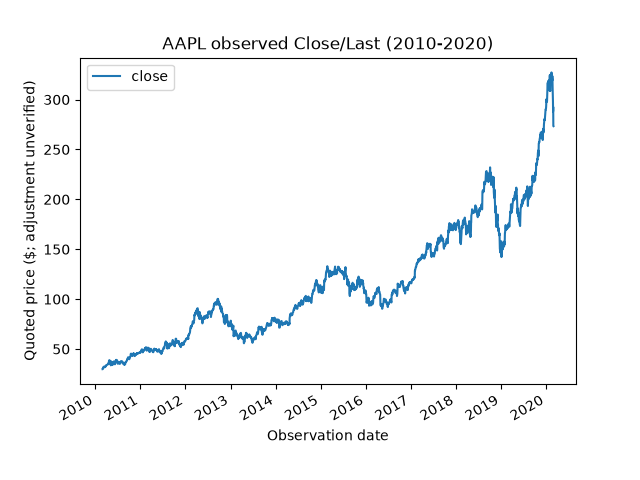

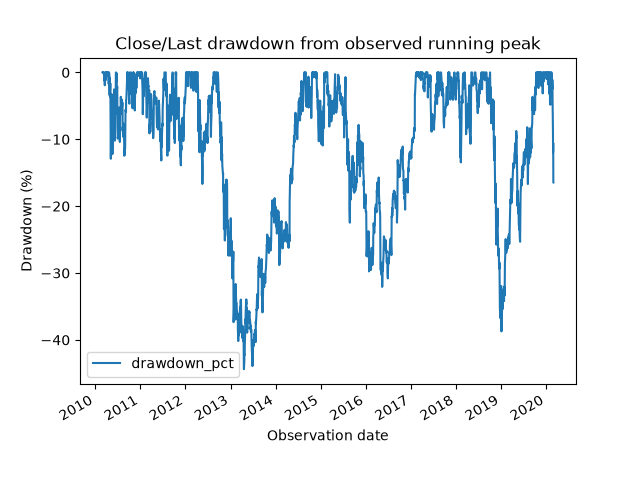

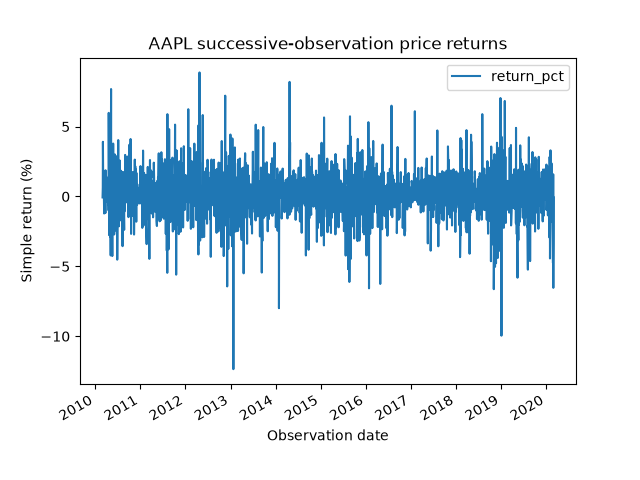

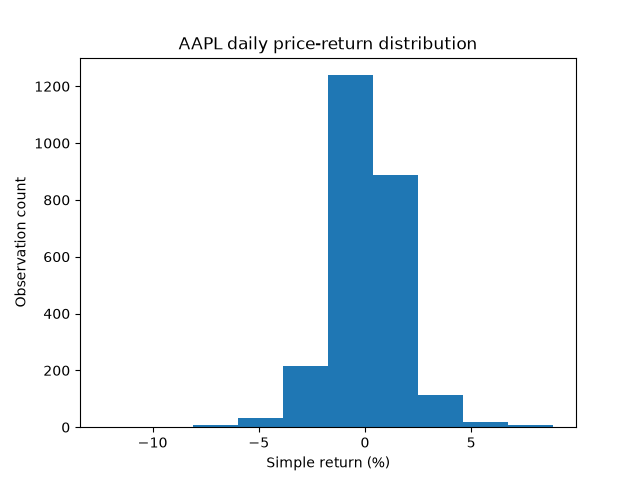

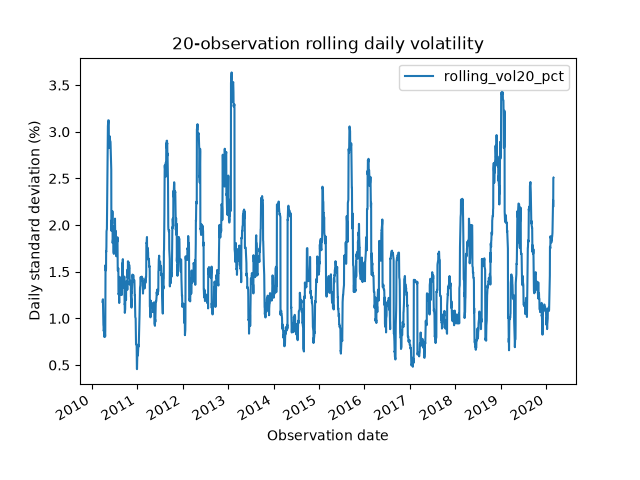

In [6]:
# 6. 初回図表：価格、価格下落率、リターン時系列・分布、局所変動
with execution_phase('initial_charts'):
    chart_specs = [
        {'kind': 'line', 'x': 'date', 'y': 'close', 'title': 'AAPL observed Close/Last (2010-2020)', 'xlabel': 'Observation date', 'ylabel': 'Quoted price ($; adjustment unverified)'},
        {'kind': 'line', 'x': 'date', 'y': 'drawdown_pct', 'title': 'Close/Last drawdown from observed running peak', 'xlabel': 'Observation date', 'ylabel': 'Drawdown (%)'},
        {'kind': 'line', 'x': 'date', 'y': 'return_pct', 'title': 'AAPL successive-observation price returns', 'xlabel': 'Observation date', 'ylabel': 'Simple return (%)'},
        {'kind': 'hist', 'x': 'return_pct', 'title': 'AAPL daily price-return distribution', 'xlabel': 'Simple return (%)', 'ylabel': 'Observation count'},
        {'kind': 'line', 'x': 'date', 'y': 'rolling_vol20_pct', 'title': '20-observation rolling daily volatility', 'xlabel': 'Observation date', 'ylabel': 'Daily standard deviation (%)'}]
    glyph_warnings = []
    for spec in chart_specs:
        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter('always')
            png = visualization.render_chart(df, **spec)
        glyph_warnings.extend(str(w.message) for w in captured if 'Glyph' in str(w.message))
        if glyph_warnings:
            raise ValueError('図表で欠落glyphを検出しました')
        output = visualization.build_image_output(png)
        display(output['data'], raw=True)
    chart_metadata = {'title': [s['title'] for s in chart_specs], 'xlabel': [s['xlabel'] for s in chart_specs], 'ylabel': [s['ylabel'] for s in chart_specs], 'legend': ['close', 'drawdown_pct', 'return_pct', 'histogram: not applicable (one series)', 'rolling_vol20_pct'], 'missing_glyphs': [], 'glyph_check': '捕捉したMatplotlib Glyph警告は0件。図表はASCIIラベル。', 'chart_count': len(chart_specs)}
    print('図表caption: 価格は価格単位、リターンと下落率は%。ローリング標準偏差は20観測で年率換算しない。')


# 方法と適用範囲

日付昇順に並べ、価格Pと単純リターン r=P_t/P_(t-1)-1、対数リターンを区別する。価格変化は端点比、下落率は収録範囲内の累積最高値比、日次変動は標本標準偏差（ddof=1）と分位点で記述する。休日の補間や外れ値の除外はしない。価格の自己相関をリターンの予測可能性と混同しない。

収録終点は2020年2月であり、2020年3月以降の相場、2020年8月の株式分割、現在の価格や将来の投資収益を扱えない。Close/Lastの調整規則と配当再投資は未確認。独立した第二データセットを取得していないため、`validate_anomalies`、`compare_datasets` による外部照合は適用できない。同じCSVの再取得SHA一致はファイル再現性の検査であり、価格の真偽や外部独立検証ではない。予測、因果推論、機械学習・クラスタリングは本依頼の記述目的とデータ限界から非適用。


# 反復依頼履歴

## 反復1：原文

全期間の日次標準偏差だけで変動を一定と解釈しないよう、年別と前半・後半・直近252観測を比較してください。単純リターンと対数リターンを切り替えた感度分析を行い、最大下落のピーク・底・回復日も確認してください。2014年の分割前後に不自然な価格断絶がないか確認し、調整規則を証明できるかどうかを区別してください。

選定理由：初回の20観測ローリング変動図で時期ごとの幅が異なる。全期間要約の代表性（前提A5）と長期価格比較の調整基準（A2）が結論に影響する。結果・証拠は直後の実行セルと最後の根拠付き所見に記録する。残る限界：独立した株価・調整データとの照合はない。

分割イベント日は補助的な既知日付。断絶不在は値の連続性の検査であって調整方式の証明ではない。外部イベント参照・独立価格照合は未実施。
最大下落経路: {"peak_date": "2012-09-19", "trough_date": "2013-04-19", "recovery_date": "2014-08-19", "drawdown_pct": -44.37686939182453, "peak_to_trough_observations": 144}
標準偏差感度: {
  "results": [
    {
      "specification": {
        "return_kind": "simple",
        "subset": "all"
      },
      "value": 1.6270602862984627
    },
    {
      "specification": {
        "return_kind": "simple",
        "subset": "first_half"
      },
      "value": 1.6780482240955785
    },
    {
      "specification": {
        "return_kind": "simple",
        "subset": "second_half"
      },
      "value": 1.5746036838316484
    },
    {
      "specification": {
        "return_kind": "simple",
        "subset": "last_252"
      },
      "value": 1.6081633295024051
    },
    {
      "specification": {
        "return_kind": "log",
        "subset": "all"
      },
      "value": 1.6294870302879176
    },
    {
      "specification": {
  

,year,n_returns,observed_year_price_change_pct,daily_std_pct,mean_daily_pct,min_daily_pct,max_daily_pct,coverage
0,2010,213,54.342387,1.633394,0.217161,-4.521167,7.686760,partial
1,2011,252,25.557943,1.653940,0.103979,-5.593999,5.888788,calendar-year observations
2,2012,250,31.400813,1.860358,0.126403,-6.434559,8.874063,calendar-year observations
3,2013,252,5.420607,1.798566,0.037322,-12.355014,5.136186,calendar-year observations
4,2014,252,37.724170,1.365688,0.136394,-7.992722,8.198169,calendar-year observations
5,2015,252,-4.638521,1.684060,-0.004716,-6.116289,5.735493,calendar-year observations
6,2016,252,10.032301,1.472166,0.048759,-6.570657,6.496328,calendar-year observations
7,2017,251,46.114661,1.113460,0.157341,-3.877670,6.098063,calendar-year observations
8,2018,251,-6.789576,1.810878,-0.011657,-6.633066,7.042158,calendar-year observations
9,2019,252,86.160771,1.649222,0.260570,-9.960740,6.833463,calendar-year observations


,date,close,return_pct
1074,2014-06-05,92.4785,0.392327
1075,2014-06-06,92.2243,-0.274875
1076,2014-06-09,93.7000,1.600121
1077,2014-06-10,94.2500,0.586980
1078,2014-06-11,93.8600,-0.413793


,return_kind,subset,n,daily_std_pct,daily_mean_pct
0,simple,all,2517,1.627060,0.101276
1,simple,first_half,1258,1.678048,0.130144
2,simple,second_half,1259,1.574604,0.072431
3,simple,last_252,252,1.608163,0.194331
4,log,all,2517,1.629487,0.087978
5,log,first_half,1258,1.678919,0.115997
6,log,second_half,1259,1.578721,0.059982
7,log,last_252,252,1.615476,0.181203


'ITERATION1={"std_stable": true, "std_max_relative_deviation": 0.03224010991390629, "mean_stable": false, "mean_max_relative_deviation": 0.9188302040813914, "full_year_std_min": 1.1134596631073683, "full_year_std_max": 1.8603575735573548, "drawdown_path": {"peak_date": "2012-09-19", "trough_date": "2013-04-19", "recovery_date": "2014-08-19", "drawdown_pct": -44.37686939182453, "peak_to_trough_observations": 144}, "extreme_absolute_over20_count": 0}'

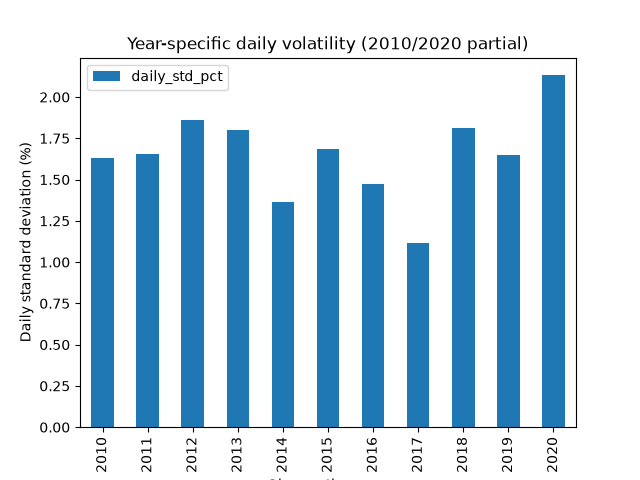

In [7]:
# 8. 反復1：期間依存性・リターン定義の感度・価格下落経路
with execution_phase('iteration_1_temporal_sensitivity'), data_write_phase('data_artifacts_cell_9'):
    annual_rows = []
    for year, group in df.groupby(df.date.dt.year):
        r = group.simple_return.dropna()
        annual_rows.append({'year': year, 'n_returns': len(r), 'observed_year_price_change_pct': float(((1 + r).prod() - 1) * 100), 'daily_std_pct': float(r.std(ddof=1) * 100), 'mean_daily_pct': float(r.mean() * 100), 'min_daily_pct': float(r.min() * 100), 'max_daily_pct': float(r.max() * 100), 'coverage': 'partial' if year in (int(df.date.dt.year.min()), int(df.date.dt.year.max())) else 'calendar-year observations'})
    annual = pd.DataFrame(annual_rows)
    display(annual)
    split_window = df.loc[df.date.between('2014-06-05', '2014-06-11'), ['date', 'close', 'return_pct']]
    display(split_window)
    print('分割イベント日は補助的な既知日付。断絶不在は値の連続性の検査であって調整方式の証明ではない。外部イベント参照・独立価格照合は未実施。')
    trough_index = int(df.drawdown_pct.idxmin())
    peak_index = int(df.loc[:trough_index, 'close'].idxmax())
    recovery = df.loc[trough_index + 1:]
    recovery = recovery.loc[recovery.close >= df.close.iloc[peak_index]]
    drawdown_path = {'peak_date': str(df.date.iloc[peak_index].date()), 'trough_date': str(df.date.iloc[trough_index].date()), 'recovery_date': str(recovery.date.iloc[0].date()) if not recovery.empty else None, 'drawdown_pct': float(df.drawdown_pct.iloc[trough_index]), 'peak_to_trough_observations': trough_index - peak_index}
    print('最大下落経路:', json.dumps(drawdown_path, ensure_ascii=False))
    def sample_returns(return_kind='simple', subset='all'):
        values = df.simple_return.dropna().to_numpy() if return_kind == 'simple' else df.log_return.dropna().to_numpy()
        half = len(values) // 2
        selections = {'all': values, 'first_half': values[:half], 'second_half': values[half:], 'last_252': values[-252:]}
        return selections[subset]
    period_plan = sensitivity.SensitivityPlan(parameter_grid={'return_kind': ['simple', 'log'], 'subset': ['all', 'first_half', 'second_half', 'last_252']}, max_runs=8)
    std_sensitivity = sensitivity.run_sensitivity(period_plan, lambda **spec: np.std(sample_returns(**spec), ddof=1) * 100, stability_tolerance=0.20)
    mean_sensitivity = sensitivity.run_sensitivity(period_plan, lambda **spec: np.mean(sample_returns(**spec)) * 100, stability_tolerance=0.20)
    print('標準偏差感度:', json.dumps(asdict(std_sensitivity), ensure_ascii=False, indent=2))
    print('平均感度（小さい基準平均の相対差は過大になり得る）:', json.dumps(asdict(mean_sensitivity), ensure_ascii=False, indent=2))
    detail = pd.DataFrame([{'return_kind': result.specification['return_kind'], 'subset': result.specification['subset'], 'n': len(sample_returns(**result.specification)), 'daily_std_pct': result.value, 'daily_mean_pct': float(sample_returns(**result.specification).mean() * 100)} for result in std_sensitivity.results])
    display(detail)
    print('事前指定した20%許容幅は比較用の運用基準で、確率的有意差検定ではない。時期変更と定義変更の効果は別々に読む。')
    interpretation1 = {'std_stable': std_sensitivity.stable, 'std_max_relative_deviation': std_sensitivity.max_relative_deviation, 'mean_stable': mean_sensitivity.stable, 'mean_max_relative_deviation': mean_sensitivity.max_relative_deviation, 'full_year_std_min': float(annual.loc[annual.coverage != 'partial', 'daily_std_pct'].min()), 'full_year_std_max': float(annual.loc[annual.coverage != 'partial', 'daily_std_pct'].max()), 'drawdown_path': drawdown_path, 'extreme_absolute_over20_count': int((df.simple_return.abs() > .20).sum())}
    display('ITERATION1=' + json.dumps(interpretation1, ensure_ascii=False))
    for spec in [{'kind': 'bar', 'x': 'year', 'y': 'daily_std_pct', 'title': 'Year-specific daily volatility (2010/2020 partial)', 'xlabel': 'Observation year', 'ylabel': 'Daily standard deviation (%)'}]:
        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter('always')
            png = visualization.render_chart(annual, **spec)
        if any('Glyph' in str(w.message) for w in captured):
            raise ValueError('Glyph警告')
        display(visualization.build_image_output(png)['data'], raw=True)
    updated_assumptions = tuple(analysis_assumptions.Assumption(a.id, '期間・リターン定義の感度分析を実行。一定変動という仮定は置かない' if a.id == 'A5' else a.statement, 'tested' if a.id == 'A5' else a.status, evidence_cell=None, impact_if_false=a.impact_if_false, conclusion_critical=a.conclusion_critical) for a in assumptions.assumptions)
    assumptions = analysis_assumptions.AnalysisAssumptionManifest(analysis_scope=assumptions.analysis_scope, assumptions=updated_assumptions, causal_scope='descriptive', sampling=assumptions.sampling)
    print('更新後前提の全finding:', json.dumps([asdict(f) for f in analysis_assumptions.check_manifest(assumptions)], ensure_ascii=False))
    (data_dir / 'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumptions), ensure_ascii=False, indent=2))
    (data_dir / 'iteration-1.json').write_text(json.dumps({'interpretation': interpretation1, 'std_sensitivity': asdict(std_sensitivity), 'mean_sensitivity': asdict(mean_sensitivity)}, ensure_ascii=False, indent=2))


# 反復依頼履歴（続き）

## 反復2：原文

部分期間を変えると平均リターンが安定しなかったため、観測平均の不確実性を時系列依存に配慮したブロック・ブートストラップで確認してください。初回に見られた裾の厚さを正規分布の基準と比較し、少数の極端な日とウィンザー化の有無が標準偏差に与える影響を調べてください。これらを将来予測や正常性の保証に使わないことも明記してください。

選定理由：反復1で平均の感度判定が不安定。一方、大きな部分期間の標準偏差は安定でも年別変動には差があり、初回の超過尖度の解釈を10区間ヒストグラムだけに依存できない。残る限界：ブートストラップは収録期間内の再標本化でありレジーム変化・未観測危機を再現しない。

裾と極端日寄与: {
  "n": 2517,
  "three_sigma_count": 36,
  "three_sigma_fraction": 0.014302741358760428,
  "normal_three_sigma_fraction": 0.0026997960632601866,
  "tail_ratio_to_normal": 5.297711761787259,
  "top_1pct_days_count": 26,
  "top_1pct_squared_deviation_share": 0.19536152863500136,
  "excess_kurtosis": 4.422175414926227
}
両裾ウィンザー化の感度: {
  "results": [
    {
      "specification": {
        "return_kind": "simple",
        "winsor_fraction": 0.0
      },
      "value": 1.6270602862984627
    },
    {
      "specification": {
        "return_kind": "simple",
        "winsor_fraction": 0.005
      },
      "value": 1.5671732571633328
    },
    {
      "specification": {
        "return_kind": "simple",
        "winsor_fraction": 0.01
      },
      "value": 1.510954522851581
    },
    {
      "specification": {
        "return_kind": "log",
        "winsor_fraction": 0.0
      },
      "value": 1.6294870302879176
    },
    {
      "specification": {
        "return_kind": "log",
 

,block_length,replicates,seed,observed_daily_mean_pct,bootstrap_95pct_low,bootstrap_95pct_high
0,5,2000,20261007,0.101276,0.038223,0.163260
1,20,2000,20261022,0.101276,0.037871,0.160163


'ITERATION2={"tails": {"n": 2517, "three_sigma_count": 36, "three_sigma_fraction": 0.014302741358760428, "normal_three_sigma_fraction": 0.0026997960632601866, "tail_ratio_to_normal": 5.297711761787259, "top_1pct_days_count": 26, "top_1pct_squared_deviation_share": 0.19536152863500136, "excess_kurtosis": 4.422175414926227}, "winsor_stable": true, "winsor_max_relative_deviation": 0.07137304300523954, "bootstrap": [{"block_length": 5, "replicates": 2000, "seed": 20261007, "observed_daily_mean_pct": 0.10127591307266574, "bootstrap_95pct_low": 0.03822317476090679, "bootstrap_95pct_high": 0.16325971538374456}, {"block_length": 20, "replicates": 2000, "seed": 20261022, "observed_daily_mean_pct": 0.10127591307266574, "bootstrap_95pct_low": 0.037870630417664336, "bootstrap_95pct_high": 0.16016332910391595}]}'

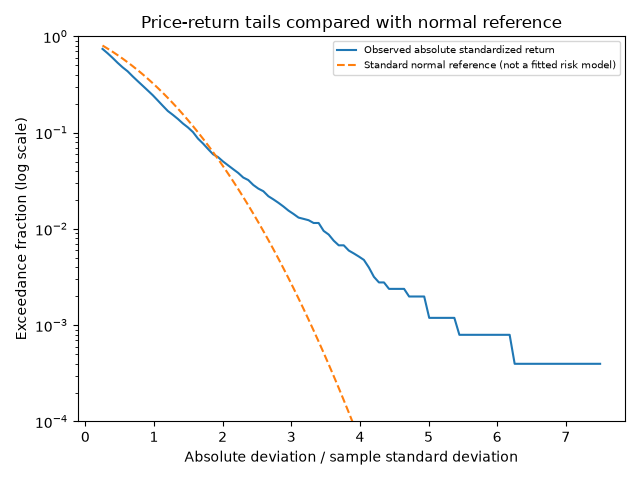

In [8]:
# 10. 反復2：裾の厚さ・極端日依存・平均推定の範囲
from scipy.stats import norm
import matplotlib.pyplot as plt
with execution_phase('iteration_2_tail_and_bootstrap'), data_write_phase('data_artifacts_cell_11'):
    values = returns.to_numpy()
    mean = float(values.mean())
    std = float(values.std(ddof=1))
    z = (values - mean) / std
    observed_tail_count = int((np.abs(z) > 3).sum())
    gaussian_tail_probability = float(2 * norm.sf(3))
    squared_deviation = (values - mean) ** 2
    top_n = int(np.ceil(len(values) * .01))
    extreme_variance_share = float(np.sort(squared_deviation)[-top_n:].sum() / squared_deviation.sum())
    tails = {'n': len(values), 'three_sigma_count': observed_tail_count, 'three_sigma_fraction': observed_tail_count / len(values), 'normal_three_sigma_fraction': gaussian_tail_probability, 'tail_ratio_to_normal': float((observed_tail_count / len(values)) / gaussian_tail_probability), 'top_1pct_days_count': top_n, 'top_1pct_squared_deviation_share': extreme_variance_share, 'excess_kurtosis': float(returns.kurt())}
    print('裾と極端日寄与:', json.dumps(tails, ensure_ascii=False, indent=2))
    def winsor_std(return_kind='simple', winsor_fraction=0.0):
        sample = sample_returns(return_kind=return_kind, subset='all')
        if winsor_fraction:
            lower, upper = np.quantile(sample, [winsor_fraction, 1 - winsor_fraction])
            sample = np.clip(sample, lower, upper)
        return float(np.std(sample, ddof=1) * 100)
    winsor_plan = sensitivity.SensitivityPlan(parameter_grid={'return_kind': ['simple', 'log'], 'winsor_fraction': [0.0, 0.005, 0.01]}, max_runs=6)
    winsor_sensitivity = sensitivity.run_sensitivity(winsor_plan, winsor_std, stability_tolerance=.20)
    print('両裾ウィンザー化の感度:', json.dumps(asdict(winsor_sensitivity), ensure_ascii=False, indent=2))
    print('ウィンザー化は価格異常の訂正ではなく感度分析のみ。初回の価格・リターンは変更しない。')
    BOOTSTRAP_SEED = 20261002
    BOOTSTRAP_REPLICATES = 2000
    bootstrap_rows = []
    for block_length in [5, 20]:
        rng = np.random.default_rng(BOOTSTRAP_SEED + block_length)
        block_count = int(np.ceil(len(values) / block_length))
        means = np.empty(BOOTSTRAP_REPLICATES)
        for b in range(BOOTSTRAP_REPLICATES):
            starts = rng.integers(0, len(values), size=block_count)
            indices = (starts[:, None] + np.arange(block_length)) % len(values)
            means[b] = values[indices.ravel()[:len(values)]].mean() * 100
        lo, hi = np.quantile(means, [.025, .975])
        bootstrap_rows.append({'block_length': block_length, 'replicates': BOOTSTRAP_REPLICATES, 'seed': BOOTSTRAP_SEED + block_length, 'observed_daily_mean_pct': mean * 100, 'bootstrap_95pct_low': float(lo), 'bootstrap_95pct_high': float(hi)})
    bootstrap = pd.DataFrame(bootstrap_rows)
    display(bootstrap)
    print('ブートストラップ前提: 選んだブロック内依存は保持するが、全期間が再標本化可能という仮定は未検証。区間は予測区間ではない。期間別平均の差や2020年3月以降の未観測相場を解消しない。')
    interpretation2 = {'tails': tails, 'winsor_stable': winsor_sensitivity.stable, 'winsor_max_relative_deviation': winsor_sensitivity.max_relative_deviation, 'bootstrap': bootstrap_rows}
    display('ITERATION2=' + json.dumps(interpretation2, ensure_ascii=False))
    thresholds = np.linspace(0.25, 7.5, 100)
    empirical = np.array([(np.abs(z) > threshold).mean() for threshold in thresholds])
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        fig, ax = plt.subplots(figsize=(6.4, 4.8))
        ax.semilogy(thresholds[empirical > 0], empirical[empirical > 0], label='Observed absolute standardized return')
        ax.semilogy(thresholds, 2 * norm.sf(thresholds), '--', label='Standard normal reference (not a fitted risk model)')
        ax.set_title('Price-return tails compared with normal reference')
        ax.set_xlabel('Absolute deviation / sample standard deviation')
        ax.set_ylabel('Exceedance fraction (log scale)')
        ax.set_ylim(1e-4, 1)
        ax.legend(fontsize=7)
        fig.tight_layout()
        buffer = io.BytesIO()
        fig.savefig(buffer, format='png')
        plt.close(fig)
    if any('Glyph' in str(w.message) for w in captured):
        raise ValueError('Glyph警告')
    display(visualization.build_image_output(buffer.getvalue())['data'], raw=True)
    bootstrap_assumption = analysis_assumptions.Assumption('A6', 'ブロック再標本化が過去の観測平均の不確実性を近似する（期間非定常は解消しない）', 'assumed', impact_if_false='ブートストラップ区間の解釈が不適切', conclusion_critical=True)
    assumptions = analysis_assumptions.AnalysisAssumptionManifest(analysis_scope=assumptions.analysis_scope, assumptions=assumptions.assumptions + (bootstrap_assumption,), causal_scope='descriptive', sampling=assumptions.sampling)
    print('最終前提manifest:', json.dumps(asdict(assumptions), ensure_ascii=False, indent=2))
    print('最終前提の全finding:', json.dumps([asdict(f) for f in analysis_assumptions.check_manifest(assumptions)], ensure_ascii=False))
    (data_dir / 'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumptions), ensure_ascii=False, indent=2))
    (data_dir / 'iteration-2.json').write_text(json.dumps({'interpretation': interpretation2, 'winsor_sensitivity': asdict(winsor_sensitivity)}, ensure_ascii=False, indent=2))


# 根拠付き所見と反復結果

**価格推移（初回分析）**：2010-03-01〜2020-02-28の2518観測。収録価格は29.8557から273.36へ変化し、端点比は+815.60%。上昇一辺倒ではなく収録範囲内の最大下落率は-44.38%。価格単位はドル記号からの推定であり、調整基準は未確認。配当込み投資収益や現在の株価との直接比較ではない。証拠：コードセル5、価格図・下落率図（セル6）。

```evidence
{"execution_count":5,"cited_value":"{\"start\": \"2010-03-01\", \"end\": \"2020-02-28\", \"price_rows\": 2518, \"return_rows\": 2517, \"start_price\": 29.8557, \"end_price\": 273.36, \"observed_price_change_pct\": 815.6040555069887, \"max_drawdown_pct\": -44.37686939182453, \"mean_daily_return_pct\": 0.10127591307266574, \"median_daily_return_pct\": 0.08908245075720522, \"daily_std_pct\": 1.6270602862984627, \"q01_pct\": -4.3892971081301555, \"q99_pct\": 4.429536374159359, \"min_daily_return_pct\": -12.355013598114095, \"max_daily_return_pct\": 8.874062968515716, \"positive_fraction\": 0.5280095351609059, \"skew\": -0.19947813173321277, \"excess_kurtosis\": 4.422175414926227, \"return_acf1\": 0.018802017992174853, \"abs_return_acf1\": 0.12380021595976351}","claim_type":"descriptive"}
```

**日次変動（初回分析）**：価格差ではなく隣接観測の比率を使った2517リターン。日次平均は0.1013%、中央値は0.0891%、標準偏差は1.6271%。1%/99%分位点は-4.39% / 4.43%、最小/最大は-12.36% / +8.87%。超過尖度4.422で大きな変動が少数含まれる。これは総収益率ではなくClose/Lastの価格変化率。営業日網羅性は未検証。証拠：セル5、時系列・分布・局所変動図（セル6）。

```evidence
{"execution_count":5,"cited_value":"{\"start\": \"2010-03-01\", \"end\": \"2020-02-28\", \"price_rows\": 2518, \"return_rows\": 2517, \"start_price\": 29.8557, \"end_price\": 273.36, \"observed_price_change_pct\": 815.6040555069887, \"max_drawdown_pct\": -44.37686939182453, \"mean_daily_return_pct\": 0.10127591307266574, \"median_daily_return_pct\": 0.08908245075720522, \"daily_std_pct\": 1.6270602862984627, \"q01_pct\": -4.3892971081301555, \"q99_pct\": 4.429536374159359, \"min_daily_return_pct\": -12.355013598114095, \"max_daily_return_pct\": 8.874062968515716, \"positive_fraction\": 0.5280095351609059, \"skew\": -0.19947813173321277, \"excess_kurtosis\": 4.422175414926227, \"return_acf1\": 0.018802017992174853, \"abs_return_acf1\": 0.12380021595976351}","claim_type":"descriptive"}
```

**隣接リターンの相関（初回分析）**：相関係数は 0.0188 (p=0.3458) で、弱い正の相関が見られます。 日次リターンの1期相関は0.0188と小さく、絶対リターンの1期相関は0.1238。後者は変動のまとまりを示唆する記述値で、予測精度の検証ではない。Pearson p値は時系列独立性を仮定した参考値で、有意性・無相関・因果関係を保証しない。証拠：セル5。

```evidence
{"execution_count":5,"cited_value":"\u76f8\u95a2\u4fc2\u6570\u306f 0.0188 (p=0.3458) \u3067\u3001\u5f31\u3044\u6b63\u306e\u76f8\u95a2\u304c\u898b\u3089\u308c\u307e\u3059\u3002","claim_type":"descriptive"}
```

**反復1の結果**：最大下落は2012-09-19の収録ピークから2013-04-19の底へ進み、2014-08-19にピーク水準を回復。完全な暦年観測の標準偏差は1.113%〜1.860%で、全期間値を常時一定とみなさない。8仕様の標準偏差感度はstable=True、max_relative_deviation=0.032240（約3.22%、許容20%）だが、平均感度はstable=False、max_relative_deviation=0.918830。大きな部分期間の標準偏差安定性は年別均一性ではない。20%を超える日次価格断絶は0件、2014年6月前後にも大きな断絶は見られないが、分割・配当調整規則を証明しない。証拠：セル9の年別表・感度表・日付窓・最大下落経路・年別図。残る限界：外部の価格照合と営業日カレンダーの照合なし。

```evidence
{"execution_count":7,"cited_value":"{\"std_stable\": true, \"std_max_relative_deviation\": 0.03224010991390629, \"mean_stable\": false, \"mean_max_relative_deviation\": 0.9188302040813914, \"full_year_std_min\": 1.1134596631073683, \"full_year_std_max\": 1.8603575735573548, \"drawdown_path\": {\"peak_date\": \"2012-09-19\", \"trough_date\": \"2013-04-19\", \"recovery_date\": \"2014-08-19\", \"drawdown_pct\": -44.37686939182453, \"peak_to_trough_observations\": 144}, \"extreme_absolute_over20_count\": 0}","claim_type":"descriptive"}
```

**反復2の結果**：平均から3標準偏差を超える日が36件（1.430%）、正規分布基準の約5.30倍。偏差平方の大きい上位約1%（26日）が全偏差平方の19.54%を占める。両裾0/0.5/1%ウィンザー化とリターン定義6仕様の標準偏差感度はstable=True、max_relative_deviation=0.071373（約7.14%、許容20%）。極端日を削除していない元データを主結果にする。過去平均の条件付きブートストラップ95%区間はブロック5日：[0.0382%, 0.1633%]；ブロック20日：[0.0379%, 0.1602%]。証拠：セル11の裾比較・感度出力・ブートストラップ表・比較図。残る限界：正規基準との差は正式な正規性検定ではない。再標本化の仮定A6は未検証で、この区間は予測区間でも将来の正の平均の証明でもない。平均の期間依存性は依然残る。

```evidence
{"execution_count":8,"cited_value":"{\"tails\": {\"n\": 2517, \"three_sigma_count\": 36, \"three_sigma_fraction\": 0.014302741358760428, \"normal_three_sigma_fraction\": 0.0026997960632601866, \"tail_ratio_to_normal\": 5.297711761787259, \"top_1pct_days_count\": 26, \"top_1pct_squared_deviation_share\": 0.19536152863500136, \"excess_kurtosis\": 4.422175414926227}, \"winsor_stable\": true, \"winsor_max_relative_deviation\": 0.07137304300523954, \"bootstrap\": [{\"block_length\": 5, \"replicates\": 2000, \"seed\": 20261007, \"observed_daily_mean_pct\": 0.10127591307266574, \"bootstrap_95pct_low\": 0.03822317476090679, \"bootstrap_95pct_high\": 0.16325971538374456}, {\"block_length\": 20, \"replicates\": 2000, \"seed\": 20261022, \"observed_daily_mean_pct\": 0.10127591307266574, \"bootstrap_95pct_low\": 0.037870630417664336, \"bootstrap_95pct_high\": 0.16016332910391595}]}","claim_type":"descriptive"}
```

# 使用したJupytermindモジュール

以下は直接importして実際に呼び出したモジュール・関数だけ。共通接頭辞は `ai_data_scientist.`。間接importや内部呼び出しは計上しない。「制御」は `benchmark/v020-exp-29-controller.ipynb` のMCP実行セルを示す。

| モジュール | 直接呼び出した関数・クラス | 使用目的・場所 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 保存先検証・データディレクトリ・Notebook直列書込み（セル1と制御） |
| language_router | detect_language | 日本語判定（セル1） |
| lifecycle | register_run, mark_execution_start, mark_execution_end, mark_write_start, mark_write_end, is_cancel_requested, mark_completed, get_run_status, wait_for_quiescence | 登録・段階ログ・失敗処理分岐・終了と静止確認（セル1、最終セル、制御）。mark_failedは例外分岐の記述のみで本実行では未呼出しのため使用済み集計外 |
| ingestion | SourceSpec, ingest | 取得CSV読込み・行数上限検査（セル3） |
| cleaning | clean_dataset | 完全重複削除と影響0行の記録（セル4） |
| eda | explore | 型・欠損・記述統計（セル4） |
| stats_analysis | correlation | 隣接リターンのPearson相関と日本語解釈（セル5） |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 列定義・来歴の確度区分、unknownとinferredの注意喚起（セル4） |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 記述的分析の前提・未解決リスクと更新（セル4、9、11） |
| data_quality | detect_anomalies | 正値・非欠損・一意性の意味的検査（セル4）。OHLC・有限値・営業日等は別途pandasで検査 |
| sensitivity | SensitivityPlan, run_sensitivity | 8仕様の期間/定義比較、6仕様のウィンザー化比較（セル9、11） |
| visualization | render_chart, build_image_output | 6図のヘルパー描画、裾比較1図のPNG MIME化（セル6、9、11） |
| insight_engine | extract_cited_value, record_insight | 保存済み実行出力から値を抽出し検証済みevidence付き所見を保存（制御）。値を手作業で根拠として捏造しない |
| notebook_audit | audit_notebook | visual_audit=Trueでコード・根拠・画像を監査（最終セル、制御） |

`mcp_gateway` は直接import・呼出しなし。ネイティブJupyter MCPツールを使用し、Python MCPClientがないため未適用。`dataset_validation.compare_datasets` と `data_quality.validate_anomalies` は独立第二データなしで未適用。`anomaly_detection` のz-score検査は異常価格と極端だが有効な日を同一視しないため未適用（意味的検査と裾の記述で代替）。機械学習・因果分析・予測は目的外・データの限界のため未適用。


# Jupytermind改善候補

**classification**: Jupytermind/MCP連携の同期改善候補（帰属未確定）

**reproduction**: 実行中の対象Notebookのセル内でproject_manager.enqueue_writeにより同じNotebookのmetadataを変更

**expected**: MCPが記録したexecution_countと画像出力が保存され、metadata更新と両立する

**observed**: 初回セル6はMCPが画像5枚と実行結果を返したが、保存ファイルではexecution_count=None、outputs=[]。セル9も計算は実行された（annualが存在）が出力0。

**impact**: 監査で未実行扱いとなり根拠と図が失われる

**workaround**: 実行セル内では対象Notebookへ書かない。対象Notebookを非アクティブにして制御Notebookからenqueue_writeでmetadata・根拠セルを更新し、再接続してMCPで実行する

**related_cells**: [6, 9]

**logs**: controllerセル6、data/integration-observation.json、MCP execute_cellセル6のimages=5とexecute_codeの保存状態検査

**attribution**: Kaggleは取得成功・SHA記録済み。端末やベンチマークランナー未使用。Copilot CLI推論ではなくMCP実行中の外部Notebook更新の整合性問題。enqueue_writeのロックはMCP保存と共有されない。Jupytermind単体の不具合と断定できずMCP側との境界調査が必要。

回避後はセル9の実行結果6出力が保存され、同一現象は再発しなかった。セル6も書込みを除去した修正版を最終再実行し保存・画像監査する。Jupytermind/MCP境界の疑いとして記録し、CLI・Kaggle・ベンチマークランナー固有問題とは区別する。

# 反復終了判断と再実行手順

追加依頼は2回で終了（上限3回）。価格の経路、年別変動、リターン定義の違い、極端日の寄与、平均推定の仮定を検討済み。残る結論上の限界は、価格調整規則の外部確認、取引所営業日の網羅性、ブートストラップの期間非定常であり、同一CSVで別の検定を追加しても解消しない。事後的に大量の検定や予測モデルを探索する価値はない。

再実行はJupyter MCPでカーネルを再起動し、対象Notebookのコードセルを昇順にexecute_cellする。取得APIも再実行しCSVのSHA-256一致を確認する。根拠markdownのexecution_countは、最終監査セルの直前に対象を非アクティブにし、制御Notebookから最新出力に再リンクする。その後に最終セルを実行し、保存後にもう一度外部の制御Notebookからread-only監査する。分析をexec/evalで代用せず、全コードをMCPで実行する。

execution_countはJupyter実行の値をそのまま使う。根拠には保存済みexecute_result/display_dataのtext/plainを使い、stream出力だけを証拠にしない（現行insight_engineの適用範囲）。実行中のNotebook自己書込みは上記の連携回避策により行わない。


In [10]:
# 15. 最終Notebook・画像監査とライフサイクル終了（対象Notebookには書かない）
try:
    with execution_phase('final_notebook_visual_audit'):
        audit_report = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
        print('Notebook監査:', json.dumps({**asdict(audit_report), 'ok': audit_report.ok}, ensure_ascii=False, indent=2))
        if not audit_report.ok:
            raise RuntimeError('Notebook監査不合格')
        saved_nb = nbformat.read(handle.notebook_path, as_version=4)
        image_count = sum('image/png' in out.get('data', {}) for c in saved_nb.cells if c.cell_type == 'code' for out in c.get('outputs', []))
        if image_count != 7:
            raise RuntimeError('必須の7図が保存されていません')
        print('保存された画像数:', image_count)
        print('前提finding（監査合格でも意味的な限界は解決しない）:', json.dumps([asdict(f) for f in analysis_assumptions.check_manifest(assumptions)], ensure_ascii=False))
    lifecycle.mark_write_start(RUN_ID)
    phase_log.append({'event': 'write_start', 'phase': 'final_artifacts', 'time': datetime.now(timezone.utc).isoformat()})
    try:
        (data_dir / 'notebook-audit-in-cell.json').write_text(json.dumps({**asdict(audit_report), 'ok': audit_report.ok}, ensure_ascii=False, indent=2))
    finally:
        lifecycle.mark_write_end(RUN_ID)
        phase_log.append({'event': 'write_end', 'phase': 'final_artifacts', 'time': datetime.now(timezone.utc).isoformat()})
    lifecycle.mark_completed(RUN_ID)
    final_status = lifecycle.wait_for_quiescence(RUN_ID, timeout_s=5)
    if final_status.state != 'completed' or final_status.active_cell_executions or final_status.pending_notebook_writes or final_status.locks_held:
        raise RuntimeError('completedかつ静止状態になっていません')
    (data_dir / 'lifecycle.json').write_text(json.dumps({'status': asdict(final_status), 'phase_log': phase_log}, ensure_ascii=False, indent=2))
    print('最終ライフサイクル:', json.dumps(asdict(final_status), ensure_ascii=False))
    print('最終セルは実行中のため初回監査では自己除外される。MCP保存後に制御Notebookでも全セル監査を実施してmetadataへ記録する。')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise


Notebook監査: {
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-29-apple-stock/notebooks/kaggle-v020-kaggle-exp-29-apple-stock.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 9,
  "executed_code_cell_count": 8,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    6,
    9,
    11
  ],
  "insight_cell_count": 5,
  "findings": [
    {
      "severity": "warning",
      "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
      "cell_index": 21
    }
  ],
  "visual_findings": [],
  "ok": true
}
保存された画像数: 7
前提finding（監査合格でも意味的な限界は解決しない）: [{"code": "unresolved_conclusion_critical_assumption", "severity": "warning", "message": "Conclusion-critical assumption 'A2' has status 'assumed', not verified/tested.", "assumption_id": "A2"}, {"code": "unresolved_conclusion_critical_assumption", "severity": "warning", "message": "Conclusion-critical 

# 保存後の最終監査記録

全コードセル9/9を上から再実行。画像7枚、根拠付き所見5件。`audit_notebook(visual_audit=True)` は `ok=True`、未実行・エラー・図表findingは0件。Kaggleから再取得したCSVのSHA-256と初回集計は一致。run_id `v020-exp-29` は `completed`、実行・書込み・ロックの残数0。

詳細はNotebook metadataの `notebook_audit` / `lifecycle` / `replay` と `data/notebook-audit-final.json` / `data/lifecycle.json` に保存。データの価格調整・営業日網羅性（A2）と再標本化近似（A6）の前提警告は残り、監査合格とは別の限界として明記済み。